# Decision Tree Classifier
## Dataset : Iris dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)

### Load the Dataset

In [2]:
df = pd.read_csv("../../Dataset/iris.csv")

### Data Information

In [3]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
df.shape

(150, 5)

In [4]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [7]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [9]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

### Separate features and target

In [12]:
X = df.drop("target", axis=1)
y = df["target"]

print("Features:")
display(X.head())
print("\nTarget:")
display(y.head())
print("\nClass Counts:")
print(y.value_counts().sort_index())

Features:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Target:


0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


Class Counts:
target
0    50
1    50
2    50
Name: count, dtype: int64


### Split training and testing data

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (120, 4)
Testing Data: (30, 4)


### Baseline Training

In [14]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
print("Baseline Model Trained Successfully")

Baseline Model Trained Successfully


### Predictions

In [15]:
y_pred = tree.predict(X_test)
comparison = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Predicted": y_pred
})
comparison.head(15)

,Actual,Predicted
0,0,0
1,2,2
2,1,1
3,1,1
4,0,0
5,1,1
6,0,0
7,0,0
8,2,2
9,1,1


### Evaluating

In [16]:
baseline_accuracy = accuracy_score(y_test, y_pred)
print("Baseline Accuracy:", round(baseline_accuracy, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Setosa", "Versicolor", "Virginica"]))

Baseline Accuracy: 0.9333

Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


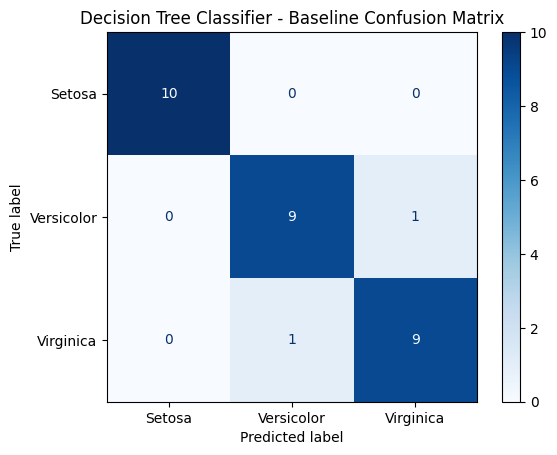

In [17]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Setosa", "Versicolor", "Virginica"]).plot(cmap="Blues")
plt.title("Decision Tree Classifier - Baseline Confusion Matrix")
plt.show()

In [18]:
train_accuracy = tree.score(X_train, y_train)
test_accuracy = tree.score(X_test, y_test)

print("Training Accuracy:", round(train_accuracy, 4))
print("Testing Accuracy:", round(test_accuracy, 4))
print("Accuracy Difference:", round(train_accuracy - test_accuracy, 4))

Training Accuracy: 1.0
Testing Accuracy: 0.9333
Accuracy Difference: 0.0667


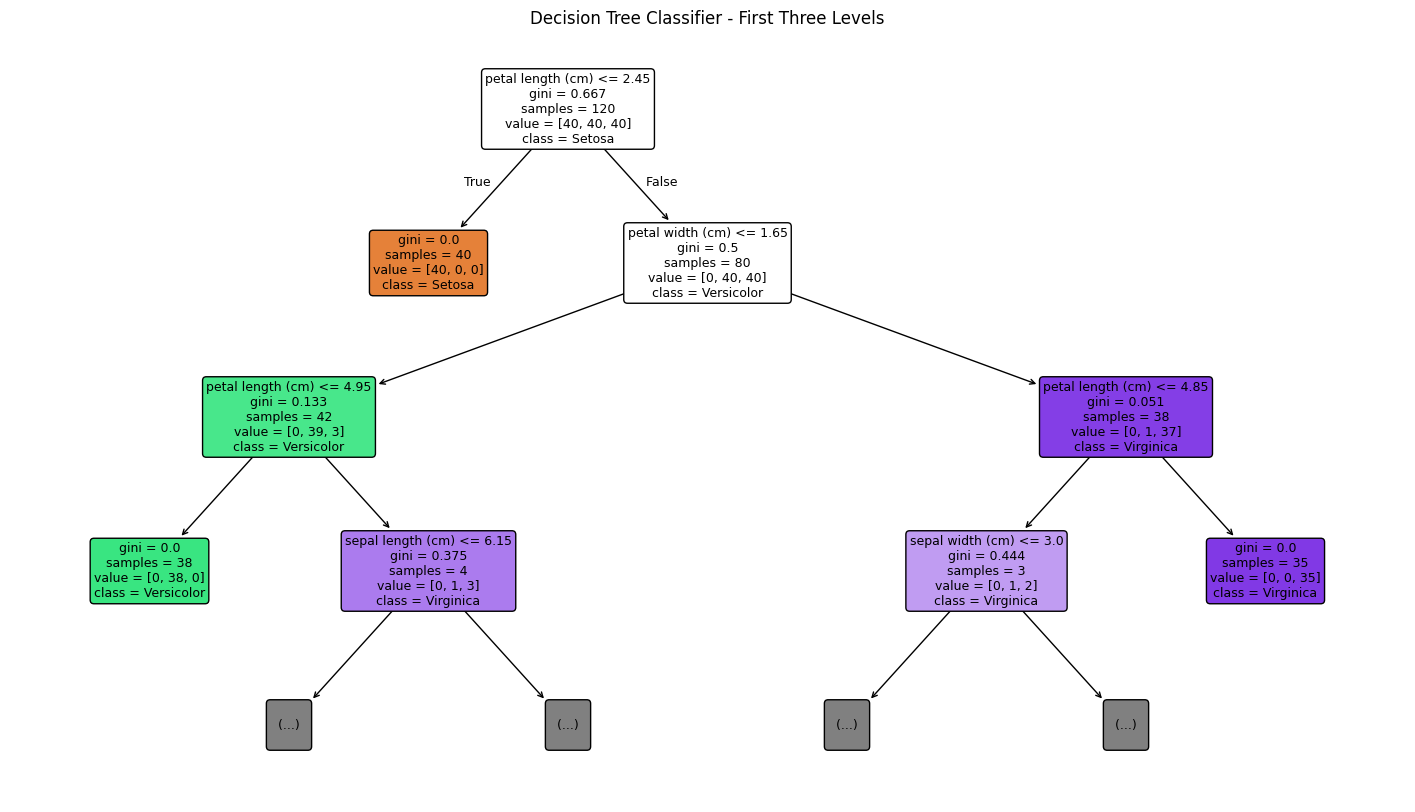

In [20]:
plt.figure(figsize=(18, 10))
plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["Setosa", "Versicolor", "Virginica"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)
plt.title("Decision Tree Classifier - First Three Levels")
plt.show()

### Hyperparameter Tuning

In [22]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, 5, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "ccp_alpha": [0.0, 0.001, 0.01]
}

In [23]:
tree = DecisionTreeClassifier(random_state=42)
grid = GridSearchCV(estimator=tree, param_grid=param_grid, cv=5, scoring="accuracy", n_jobs=-1, refit=True)
grid.fit(X_train, y_train)
print("Grid Search Completed")

Grid Search Completed


In [24]:
print("Best Parameters:")
print(grid.best_params_)
print("\nBest Cross-Validation Accuracy:")
print(round(grid.best_score_, 4))
best_tree = grid.best_estimator_
print("\nBest Model:")
print(best_tree)

Best Parameters:
{'ccp_alpha': 0.0, 'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Cross-Validation Accuracy:
0.9417

Best Model:
DecisionTreeClassifier(max_depth=4, random_state=42)


In [27]:
results = pd.DataFrame(grid.cv_results_)
results = results.sort_values(by="mean_test_score", ascending=False)
display(
    results[
        [
            "param_criterion",
            "param_max_depth",
            "param_min_samples_split",
            "param_min_samples_leaf",
            "param_ccp_alpha",
            "mean_test_score",
            "std_test_score"
        ]
    ].head(10)
)

,param_criterion,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_ccp_alpha,mean_test_score,std_test_score
207,gini,5,2,1,0.010,0.941667,0.020412
216,gini,None,2,1,0.010,0.941667,0.020412
36,gini,None,2,1,0.000,0.941667,0.020412
108,gini,4,2,1,0.001,0.941667,0.020412
117,gini,5,2,1,0.001,0.941667,0.020412
27,gini,5,2,1,0.000,0.941667,0.020412
198,gini,4,2,1,0.010,0.941667,0.020412
126,gini,None,2,1,0.001,0.941667,0.020412
18,gini,4,2,1,0.000,0.941667,0.020412
214,gini,5,5,4,0.010,0.933333,0.020412


### Evaluating the tuned model

In [28]:
y_pred_tuned = best_tree.predict(X_test)
comparison = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Predicted": y_pred_tuned
})
display(comparison)

,Actual,Predicted
0,0,0
1,2,2
2,1,1
3,1,1
4,0,0
5,1,1
6,0,0
7,0,0
8,2,2
9,1,1


In [29]:
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
print("Baseline Test Accuracy:", round(baseline_accuracy, 4))
print("Tuned Test Accuracy:", round(tuned_accuracy, 4))
print("Best CV Accuracy:", round(grid.best_score_, 4))
print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=["Setosa", "Versicolor", "Virginica"]))

Baseline Test Accuracy: 0.9333
Tuned Test Accuracy: 0.9333
Best CV Accuracy: 0.9417

Final Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



Final Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


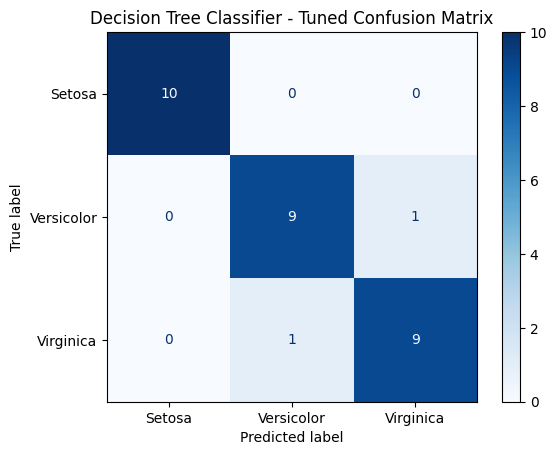

In [30]:
cm = confusion_matrix(y_test, y_pred_tuned)
print("Final Confusion Matrix:")
print(cm)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Setosa", "Versicolor", "Virginica"]  ).plot(cmap="Blues")
plt.title("Decision Tree Classifier - Tuned Confusion Matrix")
plt.show()

In [31]:
final_train_accuracy = best_tree.score(X_train, y_train)
final_test_accuracy = best_tree.score(X_test, y_test)
print("Final Training Accuracy:", round(final_train_accuracy, 4))
print("Final Testing Accuracy:", round(final_test_accuracy, 4))
print("Accuracy Difference:", round(final_train_accuracy - final_test_accuracy, 4))

Final Training Accuracy: 0.9917
Final Testing Accuracy: 0.9333
Accuracy Difference: 0.0583


### Feature Importance

In [32]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_tree.feature_importances_
}).sort_values(by="Importance", ascending=False)
display(importance)

,Feature,Importance
2,petal length (cm),0.565639
3,petal width (cm),0.411154
1,sepal width (cm),0.016878
0,sepal length (cm),0.006329


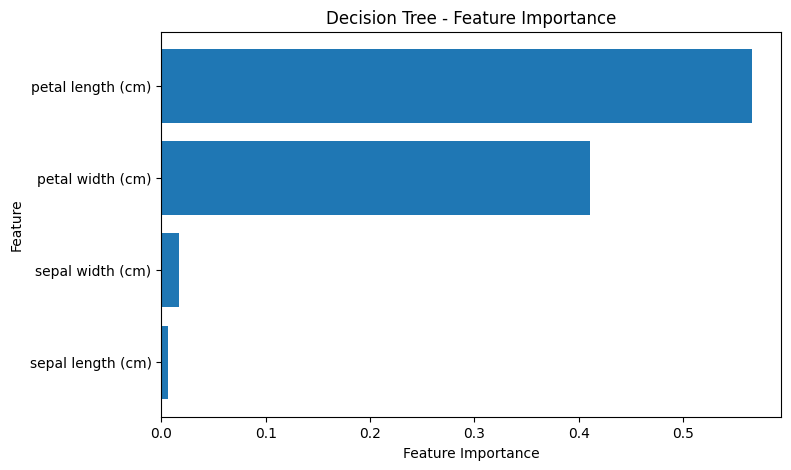

In [33]:
plt.figure(figsize=(8, 5))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Decision Tree - Feature Importance")
plt.gca().invert_yaxis()
plt.show()